# Forecast Monitoring Analysis

This notebook delivers Phase 4 outputs:
- Error metrics (mean, median, p99)
- Error vs forecast horizon
- Error vs time of day
- Wind reliability insights

Data source: backend `/data` endpoint, which already applies forecast-selection logic.

In [ ]:
import importlib
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import requests

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

In [2]:
API_BASE_URL = os.getenv('API_BASE_URL', 'http://127.0.0.1:8000')
START = os.getenv('ANALYSIS_START', '2025-01-10T00:00:00Z')
END = os.getenv('ANALYSIS_END', '2025-01-31T00:00:00Z')
HORIZONS = [0, 4, 8, 12, 24, 36, 48]
BASELINE_HORIZON = 4

print('API_BASE_URL:', API_BASE_URL)
print('START:', START)
print('END:', END)
print('HORIZONS:', HORIZONS)

API_BASE_URL: http://127.0.0.1:8000
START: 2025-01-10T00:00:00Z
END: 2025-01-31T00:00:00Z
HORIZONS: [0, 4, 8, 12, 24, 36, 48]


In [ ]:
def fetch_from_api(start: str, end: str, horizon: int, timeout: int = 90) -> pd.DataFrame:
    url = f"{API_BASE_URL}/data"
    response = requests.get(
        url,
        params={'start': start, 'end': end, 'horizon': horizon},
        timeout=timeout,
    )
    response.raise_for_status()
    payload = response.json()
    df = pd.DataFrame(payload)
    if df.empty:
        return pd.DataFrame(columns=['time', 'actual', 'forecast'])

    df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    df['actual'] = pd.to_numeric(df['actual'], errors='coerce')
    df['forecast'] = pd.to_numeric(df['forecast'], errors='coerce')
    df = df.dropna(subset=['time', 'actual', 'forecast'])
    df = df.sort_values('time').drop_duplicates(subset=['time'], keep='last')
    return df


def fetch_with_local_fallback(start: str, end: str, horizon: int) -> pd.DataFrame:
    try:
        return fetch_from_api(start=start, end=end, horizon=horizon)
    except Exception as exc:
        print(f'HTTP fetch failed for horizon={horizon}: {exc}')

    backend_dir = (Path.cwd().resolve().parent / 'backend').resolve()
    if str(backend_dir) not in sys.path:
        sys.path.insert(0, str(backend_dir))

    backend_main = importlib.import_module('main')
    get_data = getattr(backend_main, 'get_data')

    payload = get_data(start=start, end=end, horizon=horizon)
    df = pd.DataFrame(payload)
    if df.empty:
        return pd.DataFrame(columns=['time', 'actual', 'forecast'])

    df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
    df['actual'] = pd.to_numeric(df['actual'], errors='coerce')
    df['forecast'] = pd.to_numeric(df['forecast'], errors='coerce')
    df = df.dropna(subset=['time', 'actual', 'forecast'])
    df = df.sort_values('time').drop_duplicates(subset=['time'], keep='last')
    return df

In [4]:
def enrich_errors(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    out = df.copy()
    out['horizon'] = horizon
    out['error'] = out['forecast'] - out['actual']
    out['abs_error'] = out['error'].abs()
    out['hour_utc'] = out['time'].dt.hour
    return out


all_frames = []
for horizon in HORIZONS:
    frame = fetch_with_local_fallback(start=START, end=END, horizon=horizon)
    frame = enrich_errors(frame, horizon=horizon)
    all_frames.append(frame)
    print(f'horizon={horizon:>2}h rows={len(frame)}')

all_data = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
all_data.head()

HTTP fetch failed for horizon=0: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /data?start=2025-01-10T00%3A00%3A00Z&end=2025-01-31T00%3A00%3A00Z&horizon=0 (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))
horizon= 0h rows=505
HTTP fetch failed for horizon=4: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /data?start=2025-01-10T00%3A00%3A00Z&end=2025-01-31T00%3A00%3A00Z&horizon=4 (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))
horizon= 4h rows=505
HTTP fetch failed for horizon=8: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /data?start=2025-01-10T00%3A00%3A00Z&end=2025-01-

,time,actual,forecast,horizon,error,abs_error,hour_utc
0,2025-01-10 00:00:00+00:00,8275.0,8454.0,0,179.0,179.0,0
1,2025-01-10 01:00:00+00:00,7633.0,7154.0,0,-479.0,479.0,1
2,2025-01-10 02:00:00+00:00,7050.0,7004.0,0,-46.0,46.0,2
3,2025-01-10 03:00:00+00:00,6647.0,6759.0,0,112.0,112.0,3
4,2025-01-10 04:00:00+00:00,5413.0,6001.0,0,588.0,588.0,4


## Error Metrics
Required metrics are computed on absolute error in MW.

In [5]:
if all_data.empty:
    raise ValueError('No data returned for the selected interval.')

metrics = (
    all_data.groupby('horizon', as_index=False)
    .agg(
        mean_error_mw=('abs_error', 'mean'),
        median_error_mw=('abs_error', 'median'),
        p99_error_mw=('abs_error', lambda s: float(np.percentile(s, 99))),
        signed_mean_error_mw=('error', 'mean'),
        sample_count=('abs_error', 'count'),
    )
    .sort_values('horizon')
)

metrics

,horizon,mean_error_mw,median_error_mw,p99_error_mw,signed_mean_error_mw,sample_count
0,0,1123.790099,828.0,4594.12,1008.320792,505
1,4,1174.186139,910.0,4570.92,1049.457426,505
2,8,1250.073267,996.0,4518.20,1113.736634,505
3,12,1295.110891,1017.0,4565.16,1131.586139,505
4,24,1387.518812,1164.0,5261.28,1140.869307,505
5,36,1611.299010,1325.0,5556.68,1243.045545,505
6,48,1988.122807,1666.0,6595.56,1467.796992,399


## A) Error vs Forecast Horizon

In [6]:
summary_cols = ['horizon', 'mean_error_mw', 'median_error_mw', 'p99_error_mw', 'sample_count']
metrics[summary_cols]

,horizon,mean_error_mw,median_error_mw,p99_error_mw,sample_count
0,0,1123.790099,828.0,4594.12,505
1,4,1174.186139,910.0,4570.92,505
2,8,1250.073267,996.0,4518.20,505
3,12,1295.110891,1017.0,4565.16,505
4,24,1387.518812,1164.0,5261.28,505
5,36,1611.299010,1325.0,5556.68,505
6,48,1988.122807,1666.0,6595.56,399


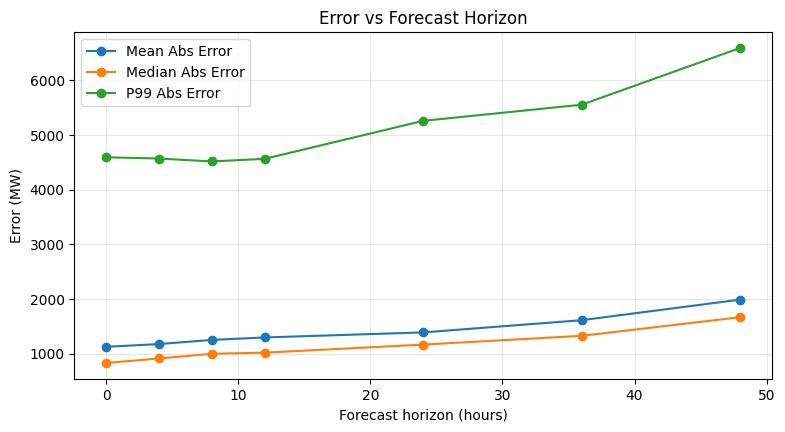

In [13]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
    ax.plot(metrics['horizon'], metrics['mean_error_mw'], marker='o', label='Mean Abs Error')
    ax.plot(metrics['horizon'], metrics['median_error_mw'], marker='o', label='Median Abs Error')
    ax.plot(metrics['horizon'], metrics['p99_error_mw'], marker='o', label='P99 Abs Error')
    ax.set_xlabel('Forecast horizon (hours)')
    ax.set_ylabel('Error (MW)')
    ax.set_title('Error vs Forecast Horizon')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()
else:
    print('matplotlib is not installed. Table above contains the required horizon analysis.')

## B) Error vs Time of Day (UTC)
Using baseline horizon for intra-day pattern analysis.

In [7]:
baseline = all_data[all_data['horizon'] == BASELINE_HORIZON].copy()

hourly_error = (
    baseline.groupby('hour_utc', as_index=False)
    .agg(
        mean_abs_error_mw=('abs_error', 'mean'),
        p90_abs_error_mw=('abs_error', lambda s: float(np.percentile(s, 90))),
        sample_count=('abs_error', 'count'),
    )
    .sort_values('hour_utc')
)

hourly_error

,hour_utc,mean_abs_error_mw,p90_abs_error_mw,sample_count
0,0,1192.090909,2745.0,22
1,1,1207.380952,2898.0,21
2,2,1295.571429,2976.0,21
3,3,1159.238095,2461.0,21
4,4,1471.285714,3122.0,21
5,5,1397.428571,3402.0,21
6,6,1473.142857,3476.0,21
7,7,1332.857143,3074.0,21
8,8,1083.333333,2297.0,21
9,9,1132.000000,2407.0,21


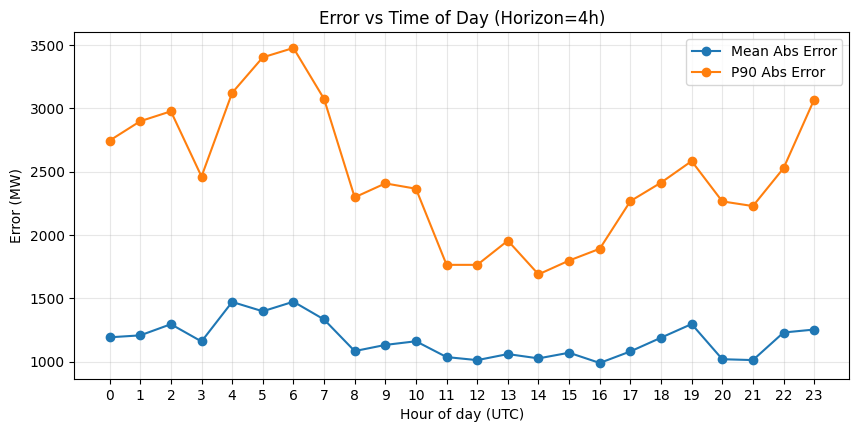

In [14]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
    ax.plot(hourly_error['hour_utc'], hourly_error['mean_abs_error_mw'], marker='o', label='Mean Abs Error')
    ax.plot(hourly_error['hour_utc'], hourly_error['p90_abs_error_mw'], marker='o', label='P90 Abs Error')
    ax.set_xticks(range(0, 24, 1))
    ax.set_xlabel('Hour of day (UTC)')
    ax.set_ylabel('Error (MW)')
    ax.set_title(f'Error vs Time of Day (Horizon={BASELINE_HORIZON}h)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

## Wind Reliability
Reliability is assessed from actual generation using the shortest-horizon sample.

In [8]:
actual_ref = all_data[all_data['horizon'] == 0]['actual'].dropna()
if actual_ref.empty:
    actual_ref = all_data['actual'].dropna()

reliability = {
    'mean_actual_mw': float(actual_ref.mean()),
    'median_actual_mw': float(actual_ref.median()),
    'p05_actual_mw': float(np.percentile(actual_ref, 5)),
    'p10_actual_mw': float(np.percentile(actual_ref, 10)),
    'p25_actual_mw': float(np.percentile(actual_ref, 25)),
}

reliability_df = pd.DataFrame([reliability])
reliability_df

,mean_actual_mw,median_actual_mw,p05_actual_mw,p10_actual_mw,p25_actual_mw
0,7682.548515,7249.0,1560.8,2310.8,3310.0


In [9]:
dependable_mw = reliability['p10_actual_mw']
share_above_dependable = float((actual_ref >= dependable_mw).mean())

print(f"Wind is above {dependable_mw:.0f} MW for {share_above_dependable*100:.1f}% of sampled intervals.")
print("Interpretation: p10 can be treated as a conservative dependable-output indicator.")

Wind is above 2311 MW for 89.9% of sampled intervals.
Interpretation: p10 can be treated as a conservative dependable-output indicator.


## Assumptions, Reasoning, Trade-offs

### Assumptions
- Backend endpoint applies correct cutoff selection (`publishTime <= startTime - horizon`).
- Data timestamps are UTC and represent 30-minute target intervals.
- Analysis window is representative of broader behavior.

### Reasoning
- Absolute error is used for operational reliability metrics because direction can cancel out in averages.
- Signed error is retained to detect systematic over/under-forecast bias.
- Hourly grouping helps identify predictable intra-day forecast weakness.

### Trade-offs
- Larger windows improve statistical stability but increase API latency.
- p99 is sensitive to outliers; combine with median for robust interpretation.
- Dependable output estimates (p10/p05) depend on season and selected time window.

## Next Actions
- Re-run with rolling monthly windows to evaluate seasonality.
- Compare reliability thresholds by month and by horizon.
- Export key metrics to CSV for reporting.